In [3]:
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import plotly.figure_factory as ff
from scipy.spatial import Delaunay
import plotly.graph_objects as go
import cvxpy as cp
from sklearn.tree import DecisionTreeRegressor

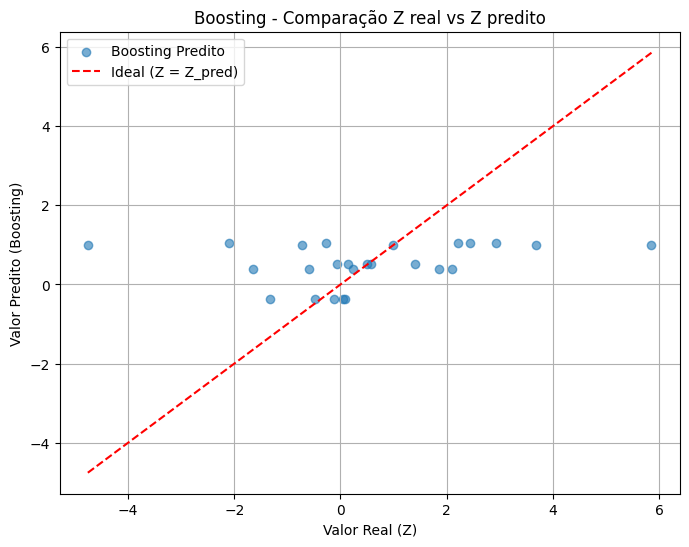

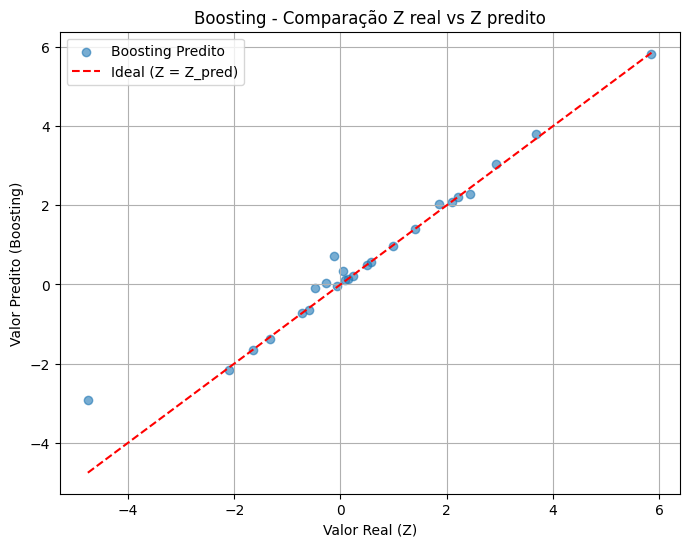

In [7]:
def boosting(file_path, B, lambda_): 
    # Lê a planilha com entradas (X, Y) e saídas (Z, Z_pred)
    df = pd.read_excel(file_path)
    Z = df['Z'].values.reshape(-1, 1)
    X = df[['X', 'Y']].values
    Z_pred = df['Z_pred'].values.reshape(-1, 1)

    # Inicialização: f(x;θ)=0 e resíduos = y
    f_preds = np.zeros_like(Z, dtype=float)
    residuals = Z.copy()

    for b in range(B):
        # (a) Ajusta stump (profundidade 1) nos resíduos
        stump = DecisionTreeRegressor(max_depth=1, random_state=rng)
        stump.fit(X, residuals)
        models.append(stump)
        
        # (b) Atualiza predição acumulada
        pred_b = stump.predict(X).reshape(-1, 1)
        f_preds += lambda_ * pred_b
        
        # (c) Atualiza resíduos
        residuals -= lambda_ * pred_b

    return f_preds, residuals, X, Z, Z_pred

def boosted_predict(X_new):
    total = np.zeros((X_new.shape[0], 1))
    for stump in models:
        total += lambda_ * stump.predict(X_new).reshape(-1, 1)
    return total

def plot_boosting_results(Z, f_preds):
    plt.figure(figsize=(8,6))
    plt.scatter(Z, f_preds, alpha=0.6, label="Boosting Predito")
    plt.plot([Z.min(), Z.max()], [Z.min(), Z.max()], 'r--', label="Ideal (Z = Z_pred)")
    plt.xlabel("Valor Real (Z)")
    plt.ylabel("Valor Predito (Boosting)")
    plt.title("Boosting - Comparação Z real vs Z predito")
    plt.legend()
    plt.grid(True)
    plt.show()

# Parâmetros
B = 6000                 # número de iterações (boosting steps)
lambda_ = 1
models = []
rng = 42

# Teste com apenas uma rede
f_preds, residuals, X, Z, Z_pred = boosting("25_model/25_model_12_6_0.xlsx", B, lambda_)
plot_boosting_results(Z, f_preds)
plot_boosting_results(Z, Z_pred)


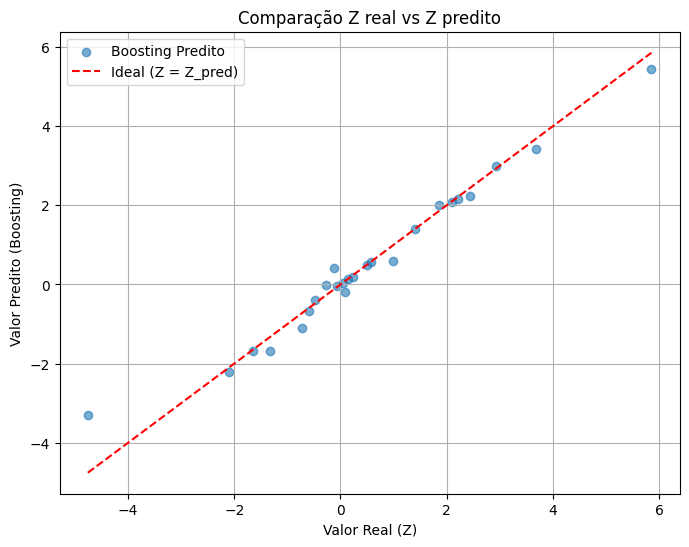

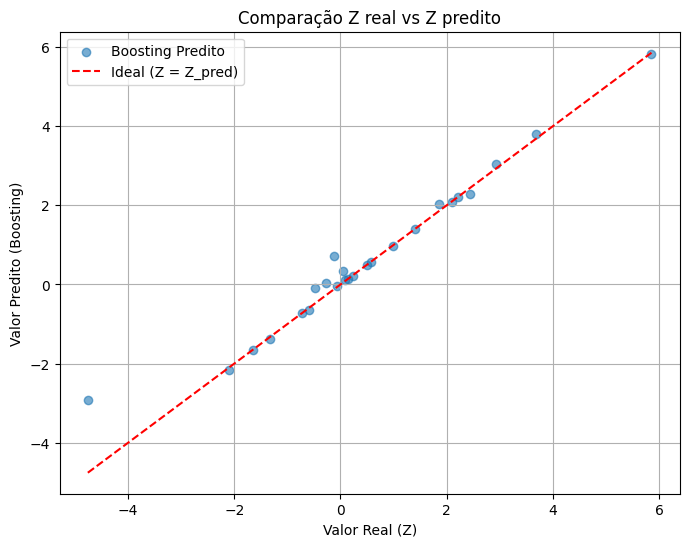

In [15]:
def boosting(file_path, B, lambda_): 
    # Lê a planilha com entradas (X, Y) e saídas (Z, Z_pred)
    df = pd.read_excel(file_path)
    Z = df['Z'].values.reshape(-1, 1)
    X = df[['X', 'Y']].values
    Z_pred = df['Z_pred'].values.reshape(-1, 1)

    # Inicialização: 
    f_preds = Z_pred.copy()
    residuals = Z - Z_pred  # erro inicial

    for b in range(B):
        # (a) Ajusta stump (profundidade 1) nos resíduos
        stump = DecisionTreeRegressor(max_depth=1, random_state=rng)
        stump.fit(X, residuals)
        models.append(stump)
        
        # (b) Atualiza predição acumulada
        pred_b = stump.predict(X).reshape(-1, 1)
        f_preds += lambda_ * pred_b
        
        # (c) Atualiza resíduos
        residuals -= lambda_ * pred_b

    return f_preds, residuals, X, Z, Z_pred

def boosted_predict(X_new):
    total = np.zeros((X_new.shape[0], 1))
    for stump in models:
        total += lambda_ * stump.predict(X_new).reshape(-1, 1)
    return total

def plot_boosting_results(Z, f_preds):
    plt.figure(figsize=(8,6))
    plt.scatter(Z, f_preds, alpha=0.6, label="Boosting Predito")
    plt.plot([Z.min(), Z.max()], [Z.min(), Z.max()], 'r--', label="Ideal (Z = Z_pred)")
    plt.xlabel("Valor Real (Z)")
    plt.ylabel("Valor Predito (Boosting)")
    plt.title("Comparação Z real vs Z predito")
    plt.legend()
    plt.grid(True)
    plt.show()


# Parâmetros
B = 6000                 # número de iterações (boosting steps)
lambda_ = 0.01
models = []
rng = 42


# Teste com apenas uma rede
f_preds, residuals, X, Z, Z_pred = boosting("25_model/25_model_12_6_0.xlsx", B, lambda_)
plot_boosting_results(Z, f_preds)
plot_boosting_results(Z, Z_pred)


In [ ]:
def boosting(file_path, B, lambda_): 
    df = pd.read_excel(file_path)
    Z = df['Z'].values.reshape(-1, 1)
    X = df[['X', 'Y']].values
    Z_pred = df['Z_pred'].values.reshape(-1, 1)

    # Inicialização: 
    f_preds = Z_pred.copy()
    residuals = Z - Z_pred  # erro inicial

    for b in range(B):
        # (a) Ajusta stump (profundidade 1) nos resíduos
        stump = DecisionTreeRegressor(max_depth=1, random_state=rng)
        stump.fit(X, residuals)
        models.append(stump)
        
        # (b) Atualiza predição acumulada
        pred_b = stump.predict(X).reshape(-1, 1)
        f_preds += lambda_ * pred_b
        
        # (c) Atualiza resíduos
        residuals -= lambda_ * pred_b

    return f_preds, residuals, X, Z, Z_pred

def boosted_predict(X_new):
    total = np.zeros((X_new.shape[0], 1))
    for stump in models:
        total += lambda_ * stump.predict(X_new).reshape(-1, 1)
    return total

def plot_boosting_results(Z, f_preds):
    plt.figure(figsize=(8,6))
    plt.scatter(Z, f_preds, alpha=0.6, label="Boosting Predito")
    plt.plot([Z.min(), Z.max()], [Z.min(), Z.max()], 'r--', label="Ideal (Z = Z_pred)")
    plt.xlabel("Valor Real (Z)")
    plt.ylabel("Valor Predito (Boosting)")
    plt.title("Comparação Z real vs Z predito")
    plt.legend()
    plt.grid(True)
    plt.show()

def salve_boost(arquivos, B, lambda_):
    resultados = pd.DataFrame()

    for arq in arquivos:
        models = []  # reinicia os modelos para cada arquivo
        
        f_preds, residuals, X, Z, Z_pred = boosting(arq, B, lambda_)
        z_pred = boosted_predict(X)
        
        # Nome da coluna baseado no arquivo
        nome_coluna = arq.split("/")[-1].replace(".xlsx", "")
        
        # Adiciona ao DataFrame
        resultados[nome_coluna] = z_pred.flatten()
    
    # Salvar todos em uma única planilha
    resultados.to_excel("boost_model/resultados_boosting.xlsx", index=False)

def salve_ensemble(arquivos):
    resultados = pd.DataFrame()

    for arq in arquivos:
        df = pd.read_excel(arq)
        Z_pred = df['Z_pred'].values.reshape(-1, 1)
        nome_coluna = arq.split("/")[-1].replace(".xlsx", "")
        resultados[nome_coluna] = Z_pred.flatten()
    
    # Salvar todos em uma única planilha
    resultados.to_excel("boost_model/resultados_normais_concatenados.xlsx", index=False)


def peso(file_path1,file_path2):
    df1 = pd.read_excel(file_path1)
    df2 = pd.read_excel(file_path2)
    Z_boost = df1.values[1:]  
    Z_pred = df2.values[1:]  
    razao= Z_pred/Z_boost
    return razao


# Parâmetros
B = 6000                 # número de iterações (boosting steps)
lambda_ = 0.01
models = []
rng = 42


# Lista de arquivos a serem processados
arquivos = [
    "25_model/25_model_12_6_0.xlsx",
    "25_model/25_model_13_9_6.xlsx",
    "25_model/25_model_20_5_0.xlsx", 
    "25_model/25_model_22_8_7.xlsx",
    "25_model/25_model_24_6_2.xlsx",
    "25_model/25_model_2_8_0.xlsx",
    "25_model/25_model_30_7_8.xlsx",
    "25_model/25_model_9_9_10.xlsx",
    "25_model/25_model_9_9_2.xlsx",
    "25_model/25_model_9_9_5.xlsx"
]

salve_boost(arquivos, B, lambda_)
salve_ensemble(arquivos)
peso= peso("boost_model/resultados_boosting.xlsx","boost_model/resultados_normais_concatenados.xlsx")
print(peso)

[[ 3.09887083e+01 -5.55601344e+00 -3.38283792e+00 -1.07346761e+00
  -8.29619545e-01 -9.66421876e-01 -7.61779592e-01 -7.77854524e-01
  -8.76858433e-01 -1.00526074e+00]
 [ 7.70264895e+00  1.14688336e+01  1.56144367e+01  1.45315212e+01
   1.89386145e+01  1.00425723e+02  7.18657445e+01  2.47640474e+02
  -1.42736870e+02 -5.58623880e+01]
 [ 5.57869084e+01  2.19214019e+02  1.15977760e+02 -4.96090334e+01
  -4.65557967e+01 -2.53122132e+01 -2.75055520e+01 -8.91801884e+01
   8.00046976e+01  2.73536134e+01]
 [-5.18924983e+01 -1.43175955e-01  2.49025523e+00  1.46575311e+00
   4.65144475e-01  2.92626374e-01  1.78308029e-01  3.16205036e-01
   2.94807854e-01  2.63311037e-01]
 [-2.35504987e+00 -6.90975543e-01  3.86481257e-01  2.13870724e-01
   5.25911867e-01  1.03561104e+01  6.88690063e-01  2.56059925e+00
   2.48294464e+00  2.00328965e+00]
 [-9.65772038e+01  1.38568424e+01  1.43024095e+00  3.08737242e+00
   2.01802400e+00  2.56043328e+00  2.39459812e+00  1.64944468e+00
   1.77720451e+00  2.07382849e+00

In [30]:
def boosting(file_path, B, lambda_): 
    df = pd.read_excel(file_path)
    Z = df['Z'].values.reshape(-1, 1)
    X = df[['X', 'Y']].values
    Z_pred = df['Z_pred'].values.reshape(-1, 1)

    # Inicialização: 
    f_preds = Z_pred.copy()
    residuals = Z - Z_pred  # erro inicial

    for b in range(B):
        # (a) Ajusta stump (profundidade 1) nos resíduos
        stump = DecisionTreeRegressor(max_depth=1, random_state=rng)
        stump.fit(X, residuals)
        models.append(stump)
        
        # (b) Atualiza predição acumulada
        pred_b = stump.predict(X).reshape(-1, 1)
        f_preds += lambda_ * pred_b
        
        # (c) Atualiza resíduos
        residuals -= lambda_ * pred_b

    return f_preds, residuals, X, Z, Z_pred

def boosted_predict(X_new):
    total = np.zeros((X_new.shape[0], 1))
    for stump in models:
        total += lambda_ * stump.predict(X_new).reshape(-1, 1)
    return total

def plot_boosting_results(Z, f_preds):
    plt.figure(figsize=(8,6))
    plt.scatter(Z, f_preds, alpha=0.6, label="Boosting Predito")
    plt.plot([Z.min(), Z.max()], [Z.min(), Z.max()], 'r--', label="Ideal (Z = Z_pred)")
    plt.xlabel("Valor Real (Z)")
    plt.ylabel("Valor Predito (Boosting)")
    plt.title("Comparação Z real vs Z predito")
    plt.legend()
    plt.grid(True)
    plt.show()

def salve_boost(arquivos, B, lambda_):
    resultados = pd.DataFrame()

    for arq in arquivos:
        models = []  # reinicia os modelos para cada arquivo
        
        f_preds, residuals, X, Z, Z_pred = boosting(arq, B, lambda_)
        z_pred = boosted_predict(X)
        
        # Nome da coluna baseado no arquivo
        nome_coluna = arq.split("/")[-1].replace(".xlsx", "")
        
        # Adiciona ao DataFrame
        resultados[nome_coluna] = z_pred.flatten()
    
    # Salvar todos em uma única planilha
    resultados.to_excel("boost_model/resultados_boosting1000.xlsx", index=False)

def salve_ensemble(arquivos):
    resultados = pd.DataFrame()

    for arq in arquivos:
        df = pd.read_excel(arq)
        Z_pred = df['Z_pred'].values.reshape(-1, 1)
        nome_coluna = arq.split("/")[-1].replace(".xlsx", "")
        resultados[nome_coluna] = Z_pred.flatten()
    
    # Salvar todos em uma única planilha
    resultados.to_excel("boost_model/resultados_normais_concatenados1000.xlsx", index=False)


def peso(file_path1,file_path2):
    df1 = pd.read_excel(file_path1)
    df2 = pd.read_excel(file_path2)
    Z_boost = df1.values
    Z_pred = df2.values  
    razao= Z_boost/Z_pred
    return razao

def superficie(file_paths):
    peso_d= peso("boost_model/resultados_boosting1000.xlsx","boost_model/resultados_normais_concatenados1000.xlsx")
    print(len(peso_d))
    # Leitura dos dados e extração de 'Z_pred' reshape em array coluna
    Z_preds = [pd.read_excel(fp)['Z_pred'].values.reshape(-1, 1) for fp in file_paths]
    Z_pred_total = np.hstack(Z_preds)
    Z_media = np.mean(Z_pred_total, axis=1, keepdims=True)
    Z_med_art= np.mean(peso_d*Z_pred_total, axis=1, keepdims=True)

    df = pd.read_excel("1000_model/1000_model_40_9_1.xlsx")
    Z_mse = df['Z'].values.reshape(-1, 1)

    x = np.linspace(-2, 2, 32)
    y = np.linspace(-2, 2, 32)
    X, Y = np.meshgrid(x, y)
    Z = 3*(1-X)**2 * np.exp(-(X**2) - (Y+1)**2) - 10*(X/5 - X**3 - Y**5) * np.exp(-X**2 - Y**2) - 1/3 * np.exp(-(X+1)**2 - Y**2)
    points = np.column_stack((X.flatten(), Y.flatten()))
    tri = Delaunay(points)
            
    fig_original = ff.create_trisurf(x=X.flatten(), y=Y.flatten(), z=Z.flatten(), 
                                            simplices=tri.simplices, colormap='Greys',
                                            title='Surface Fit - Original Values')
    fig_predicted = ff.create_trisurf(x=X.flatten(), y=Y.flatten(), z= Z_med_art.flatten(), 
                                            simplices=tri.simplices, colormap='Viridis',
                                            title='Surface Fit - Predicted Values')


    data = [fig_original.data[0], fig_predicted.data[0]]
    fig = go.Figure(data=data)
    fig.update_layout(
    title=' ',
    autosize=False,
    width=800,
    height=800,
    margin=dict(l=65, r=50, b=65, t=90),
    scene=dict(
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1),
        xaxis=dict(
            title=dict(text='x₁', font=dict(family='Times New Roman', size=26)),
            backgroundcolor='white',
            gridcolor='black',
            zerolinecolor='black',
            tickfont=dict(family='Times New Roman', size=16)
        ),
        yaxis=dict(
            title=dict(text='x₂', font=dict(family='Times New Roman', size=26)),
            backgroundcolor='white',
            gridcolor='black',
            zerolinecolor='black',
            tickfont=dict(family='Times New Roman', size=16)
        ),
        zaxis=dict(
            title=dict(text='f(x)', font=dict(family='Times New Roman', size=24)),
            backgroundcolor='white',
            gridcolor='black',
            zerolinecolor='black',
            tickfont=dict(family='Times New Roman', size=16)
        )
    ),
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=16)  # fonte global
)


    fig.show()

    mse = np.mean((Z_mse - Z_media) ** 2)

    print(f'MSE: {mse}')




# Parâmetros
B = 6000                 # número de iterações (boosting steps)
lambda_ = 0.01
models = []
rng = 42


# Lista de arquivos a serem processados
arquivos = [
    "1000_model/1000_model_12_6_0.xlsx",
    "1000_model/1000_model_13_9_6.xlsx",
    "1000_model/1000_model_20_5_0.xlsx",
    "1000_model/1000_model_22_8_7.xlsx",
    "1000_model/1000_model_24_6_2.xlsx",
    "1000_model/1000_model_2_8_0.xlsx",
    "1000_model/1000_model_30_7_8.xlsx",
    "1000_model/1000_model_9_9_10.xlsx",
    "1000_model/1000_model_9_9_2.xlsx",
    "1000_model/1000_model_9_9_5.xlsx"
]

salve_boost(arquivos, B, lambda_)
salve_ensemble(arquivos)
superficie([
    "1000_model/1000_model_12_6_0.xlsx",
    "1000_model/1000_model_13_9_6.xlsx",
    "1000_model/1000_model_20_5_0.xlsx",
    "1000_model/1000_model_22_8_7.xlsx",
    "1000_model/1000_model_24_6_2.xlsx",
    "1000_model/1000_model_2_8_0.xlsx",
    "1000_model/1000_model_30_7_8.xlsx",
    "1000_model/1000_model_9_9_10.xlsx",
    "1000_model/1000_model_9_9_2.xlsx",
    "1000_model/1000_model_9_9_5.xlsx"
])


1024


IndexError: list index out of range

In [ ]:
def superficie(file_paths):

    # Leitura dos dados e extração de 'Z_pred' reshape em array coluna
    Z_preds = [pd.read_excel(fp)['Z_pred'].values.reshape(-1, 1) for fp in file_paths]
    Z_pred_total = np.hstack(Z_preds)
    Z_media = np.mean(Z_pred_total, axis=1, keepdims=True)
    desvio_padrao = np.std(Z_pred_total, axis=1, keepdims=True)

    df = pd.read_excel("1000_model/1000_model_40_9_1.xlsx")
    Z_mse = df['Z'].values.reshape(-1, 1)

    x = np.linspace(-2, 2, 32)
    y = np.linspace(-2, 2, 32)
    X, Y = np.meshgrid(x, y)
    Z = 3*(1-X)**2 * np.exp(-(X**2) - (Y+1)**2) - 10*(X/5 - X**3 - Y**5) * np.exp(-X**2 - Y**2) - 1/3 * np.exp(-(X+1)**2 - Y**2)
    points = np.column_stack((X.flatten(), Y.flatten()))
    tri = Delaunay(points)
            
    fig_original = ff.create_trisurf(x=X.flatten(), y=Y.flatten(), z=Z.flatten(), 
                                            simplices=tri.simplices, colormap='Greys',
                                            title='Surface Fit - Original Values')
    fig_predicted = ff.create_trisurf(x=X.flatten(), y=Y.flatten(), z= Z_media.flatten(), 
                                            simplices=tri.simplices, colormap='Viridis',
                                            title='Surface Fit - Predicted Values')


    data = [fig_original.data[0], fig_predicted.data[0]]
    fig = go.Figure(data=data)
    fig.update_layout(
    title=' ',
    autosize=False,
    width=800,
    height=800,
    margin=dict(l=65, r=50, b=65, t=90),
    scene=dict(
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1),
        xaxis=dict(
            title=dict(text='x₁', font=dict(family='Times New Roman', size=26)),
            backgroundcolor='white',
            gridcolor='black',
            zerolinecolor='black',
            tickfont=dict(family='Times New Roman', size=16)
        ),
        yaxis=dict(
            title=dict(text='x₂', font=dict(family='Times New Roman', size=26)),
            backgroundcolor='white',
            gridcolor='black',
            zerolinecolor='black',
            tickfont=dict(family='Times New Roman', size=16)
        ),
        zaxis=dict(
            title=dict(text='f(x)', font=dict(family='Times New Roman', size=24)),
            backgroundcolor='white',
            gridcolor='black',
            zerolinecolor='black',
            tickfont=dict(family='Times New Roman', size=16)
        )
    ),
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=16)  # fonte global
)


    fig.show()

    mse = np.mean((Z_mse - Z_media) ** 2)

    print(f'MSE: {mse}')

superficie([
    "1000_model/1000_model_12_6_0.xlsx",
    "1000_model/1000_model_13_9_6.xlsx",
    "1000_model/1000_model_20_5_0.xlsx",
    "1000_model/1000_model_22_8_7.xlsx",
    "1000_model/1000_model_24_6_2.xlsx",
    "1000_model/1000_model_2_8_0.xlsx",
    "1000_model/1000_model_30_7_8.xlsx",
    "1000_model/1000_model_9_9_10.xlsx",
    "1000_model/1000_model_9_9_2.xlsx",
    "1000_model/1000_model_9_9_5.xlsx"
])


MSE: 0.6780546299130448
